In [1]:
# Simple consumer-metrics analysis (one notebook cell)
# - Reads all consumer CSVs
# - Makes 3 plots: throughput, p99, violation rate
# - Saves 2 merged CSVs

import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== change this path only ======
FILES = glob.glob("../results/20260217_204646/consumer/consumer-sts-0_consumer-result/metrics/consumer_metrics_run-20260217-202934_consumer-sts-*.csv")  # or "./consumer_metrics_run-*_consumer-sts-*.csv"
## ===================================

if not FILES:
    raise FileNotFoundError("No CSV files found. Update FILES glob pattern.")

In [2]:

def pod_from_name(path: str) -> str:
    m = re.search(r"(consumer-sts-\d+)", os.path.basename(path))
    return m.group(1) if m else "unknown"


In [3]:
# 1) load + concat
dfs = []
for f in sorted(FILES):
    df = pd.read_csv(f)
    if "pod" not in df.columns:
        df["pod"] = pod_from_name(f)
    df["file"] = os.path.basename(f)

    # numeric coercion (skip known string cols)
    for c in df.columns:
        if c in ("pod", "traffic_mode", "topics", "file"):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


In [4]:
data

,pod,traffic_mode,topics,window_total,window_viol,msg_rate_window,lat_window_seconds,lat_count_window,lat_p95_ms,lat_p99_ms,cpu_percent,mem_percent,uptime_sec,total_lag,max_lag,lag_skew_ratio,consumed_total,file
0,consumer-sts-0,balanced,B0-R100-20260217-202934_0,227,15,3.783333,30.0,227,815.127,1684.758,0.0,17.4,30.030,0.0,0.0,0.000000,227,consumer_metrics_run-20260217-202934_consumer-...
1,consumer-sts-0,balanced,B0-R100-20260217-202934_0,596,78,9.933333,30.0,369,2049.110,2963.299,7.3,17.3,60.049,10.0,3.0,3.900000,596,consumer_metrics_run-20260217-202934_consumer-...
2,consumer-sts-0,balanced,B0-R100-20260217-202934_0,869,95,14.483333,30.0,499,908.219,2100.582,6.9,17.3,90.078,13.0,3.0,3.000000,1096,consumer_metrics_run-20260217-202934_consumer-...
3,consumer-sts-0,balanced,B0-R100-20260217-202934_0,1571,106,26.183333,30.0,1071,934.125,1579.780,6.7,17.4,120.108,27.0,7.0,3.370370,2167,consumer_metrics_run-20260217-202934_consumer-...
4,consumer-sts-0,balanced,B0-R100-20260217-202934_0,2285,128,38.083333,30.0,1214,428.905,917.178,7.0,17.3,150.139,22.0,6.0,3.545455,3381,consumer_metrics_run-20260217-202934_consumer-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,consumer-sts-7,balanced,B0-R100-20260217-202934_0,2444,129,40.733333,30.0,1215,461.467,1123.125,10.4,16.0,690.577,26.0,6.0,3.000000,24785,consumer_metrics_run-20260217-202934_consumer-...
212,consumer-sts-7,balanced,B0-R100-20260217-202934_0,2428,142,40.466667,30.0,1213,786.510,1483.921,11.2,16.0,720.592,26.0,6.0,3.000000,25998,consumer_metrics_run-20260217-202934_consumer-...
213,consumer-sts-7,balanced,B0-R100-20260217-202934_0,2299,160,38.316667,30.0,1086,878.612,1563.990,11.1,16.0,750.623,30.0,5.0,2.166667,27084,consumer_metrics_run-20260217-202934_consumer-...
214,consumer-sts-7,balanced,B0-R100-20260217-202934_0,2255,202,37.583333,30.0,1169,1651.038,2497.089,10.4,15.8,780.631,66.0,20.0,3.939394,28253,consumer_metrics_run-20260217-202934_consumer-...


In [17]:
# 2) basic derived columns
data = data.sort_values(["pod", "uptime_sec"]).reset_index(drop=True)
data["viol_rate"] = np.where(data["window_total"] > 0, data["window_viol"] / data["window_total"], np.nan)


In [29]:
import numpy as np

# window size (seconds). Your data uses 30.0
win = float(data["lat_window_seconds"].mode().iloc[0])

# bucket uptime (0–29 -> 0, 30–59 -> 30, etc.)
data["t_bucket"] = (np.floor(data["uptime_sec"] / win) * win).astype(int)

cluster = (
    data.groupby("t_bucket", as_index=False)
        .agg(
            pods=("pod", "nunique"),
            throughput=("msg_rate_window", "sum"),
            p99_max=("lat_p99_ms", "max"),
            p99_med=("lat_p99_ms", "median"),
            window_total=("window_total", "sum"),
            window_viol=("window_viol", "sum"),
            total_lag=("total_lag", "sum"),
            max_lag=("max_lag", "max"),
        )
)

cluster["viol_rate"] = np.where(
    cluster["window_total"] > 0,
    cluster["window_viol"] / cluster["window_total"],
    np.nan
)

# print("Pods in merged data:", sorted(data["pod"].unique()))
# print("Pods per bucket (should be 8):", cluster["pods"].value_counts().to_dict())


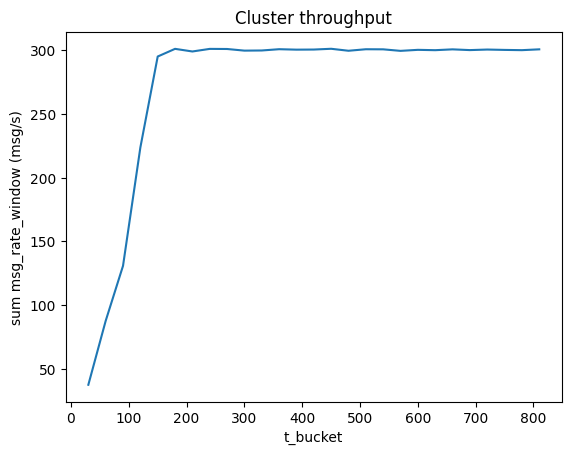

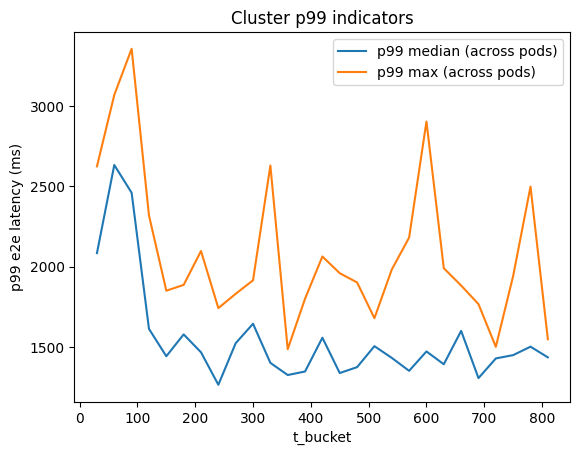

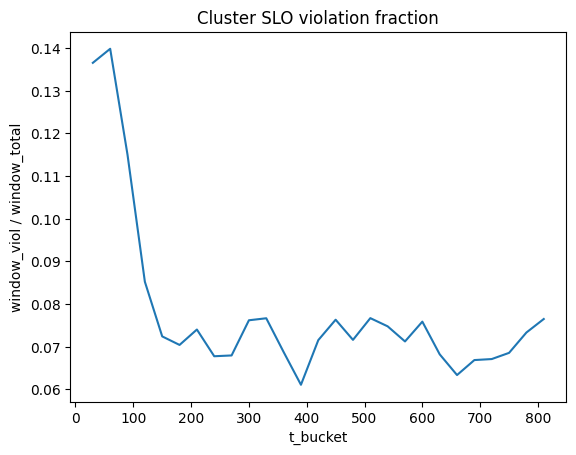

Saved ./analysis_out/per_pod_merged.csv and ./analysis_out/cluster_agg.csv


In [26]:


# 4) plots
plt.figure()
plt.plot(cluster["t_bucket"], cluster["throughput"])
plt.xlabel("t_bucket")
plt.ylabel("sum msg_rate_window (msg/s)")
plt.title("Cluster throughput")
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["p99_med"], label="p99 median (across pods)")
plt.plot(cluster["t_bucket"], cluster["p99_max"], label="p99 max (across pods)")
plt.xlabel("t_bucket")
plt.ylabel("p99 e2e latency (ms)")
plt.title("Cluster p99 indicators")
plt.legend()
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["viol_rate"])
plt.xlabel("t_bucket")
plt.ylabel("window_viol / window_total")
plt.title("Cluster SLO violation fraction")
plt.show()

# 5) save merged outputs
os.makedirs("./analysis_out", exist_ok=True)
data.to_csv("./analysis_out/per_pod_merged.csv", index=False)
cluster.to_csv("./analysis_out/cluster_agg.csv", index=False)
print("Saved ./analysis_out/per_pod_merged.csv and ./analysis_out/cluster_agg.csv")


In [27]:
data["t_bucket"].nunique()

27

In [28]:
data["pod"].nunique()

8

In [23]:
import pandas as pd
import numpy as np

data = pd.read_csv("./analysis_out/per_pod_merged.csv")

# Use the window size that exists in your data (usually 30 seconds)
win = float(data["lat_window_seconds"].mode().iloc[0])

# Bucket uptime into windows
data["t_bucket"] = (np.floor(data["uptime_sec"] / win) * win).astype(int)

# Cluster aggregation per time window
cluster = (
    data.groupby("t_bucket", as_index=False)
      .agg(
          pods=("pod", "nunique"),
          throughput=("msg_rate_window", "sum"),   # <-- cluster throughput
          total_lag=("total_lag", "sum"),          # <-- cluster lag sum
          max_lag=("max_lag", "max"),              # <-- worst partition lag
          p99_max=("lat_p99_ms", "max"),
          p99_med=("lat_p99_ms", "median"),
          window_total=("window_total", "sum"),
          window_viol=("window_viol", "sum"),
      )
)

cluster["viol_rate"] = np.where(
    cluster["window_total"] > 0,
    cluster["window_viol"] / cluster["window_total"],
    np.nan
)

# Show the last ~10 windows (steady-state)
cluster.tail(10)[["t_bucket","pods","throughput","total_lag","max_lag","p99_med","p99_max","viol_rate"]]


,t_bucket,pods,throughput,total_lag,max_lag,p99_med,p99_max,viol_rate
17,540,8,300.683334,179.0,7.0,1432.1545,1981.356,0.074774
18,570,8,299.483334,187.0,10.0,1351.6290,2180.304,0.071234
19,600,8,300.283333,225.0,11.0,1472.1190,2901.965,0.075873
20,630,8,300.016666,185.0,8.0,1392.5480,1989.499,0.068218
21,660,8,300.666666,228.0,8.0,1600.0490,1882.210,0.063359
22,690,8,300.083333,192.0,8.0,1306.4615,1766.345,0.066870
23,720,8,300.516667,214.0,9.0,1428.7485,1500.707,0.067107
24,750,8,300.233334,224.0,10.0,1449.4390,1942.247,0.068558
25,780,8,300.033333,267.0,20.0,1501.8195,2497.089,0.073325
26,810,8,300.683335,238.0,11.0,1435.5230,1547.926,0.076492


In [25]:
#sorted(data["pod"].unique()), data["pod"].nunique()
